# Understanding Winger Analysis Methodology

This document provides a detailed explanation of the code used to analyze and cluster winger profiles based on their performance metrics. The analysis involves several steps, including data preprocessing, clustering, visualization, and interpretation of results.

## 1. **Data Loading and Preprocessing**

### **1.1 Importing Libraries**
The code begins by importing necessary Python libraries:
- **Pandas** and **NumPy** for data manipulation.
- **Matplotlib** and **Seaborn** for data visualization.
- **Scikit-learn** for machine learning tasks such as scaling, clustering, and dimensionality reduction.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os
```

### **1.2 Loading the Data**
The dataset is loaded from a CSV file named `combined_winger_analysis.csv`. This file is assumed to contain performance metrics for wingers.

```python
data = pd.read_csv('combined_winger_analysis.csv')
```

### **1.3 Defining Features**
The features used for analysis are defined. These features represent different aspects of a winger's performance:
- **finishing_quality**: Ability to convert chances into goals.
- **chance_creation**: Ability to create scoring opportunities.
- **ball_progression**: Ability to advance the ball up the field.
- **one_v_one**: Ability to win one-on-one duels.
- **off_ball_movement**: Movement without the ball to create space.
- **defensive_contribution**: Contribution to defensive duties.

```python
features = [
    'finishing_quality', 
    'chance_creation', 
    'ball_progression', 
    'one_v_one', 
    'off_ball_movement', 
    'defensive_contribution'
]
```

### **1.4 Calculating Relative Strengths**
The relative strengths of each winger are calculated by subtracting the mean value of each feature from the individual player's values. This helps in understanding how each player performs relative to the average.

```python
winger_means = data[features].mean(axis=1)
relative_strengths = pd.DataFrame()
for feature in features:
    relative_strengths[feature] = data[feature] - winger_means
```

## 2. **Clustering Analysis**

### **2.1 Determining the Optimal Number of Clusters**
The code uses the **Elbow Method** and **Silhouette Scores** to determine the optimal number of clusters for K-means clustering.

- **Elbow Method**: Plots the inertia (sum of squared distances to the nearest cluster center) for different numbers of clusters. The "elbow" point indicates the optimal number of clusters.
- **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. Higher scores indicate better-defined clusters.

```python
max_clusters = 10
inertias = []
silhouette_scores = []

scaler = StandardScaler()
scaled_data = scaler.fit_transform(relative_strengths)
scaled_df = pd.DataFrame(scaled_data, columns=features)

K = range(2, max_clusters + 1)
for k in K:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(scaled_df)
    inertias.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(scaled_df, kmeans_test.labels_))
```

### **2.2 Visualizing Clustering Metrics**
The results of the Elbow Method and Silhouette Scores are visualized using Matplotlib.

```python
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(K, inertias, 'bx-')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')

# Silhouette scores
ax2.plot(K, silhouette_scores, 'rx-')
ax2.set_xlabel('k (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis for Optimal k')

plt.tight_layout()
plt.show()
```

### **2.3 Applying K-means Clustering**
Based on the analysis, the code proceeds with K-means clustering using `n_clusters=3`. The resulting clusters are labeled as:
- **Traditional Winger**
- **Inverted Winger**
- **Complete Forward**

```python
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(relative_strengths)

data['cluster'] = labels
profile_styles = ['Traditional Winger', 'Inverted Winger', 'Complete Forward']
```

### **2.4 Printing Cluster Members and Characteristics**
The code prints the members of each cluster along with their relative strengths.

```python
for i in range(n_clusters):
    print(f"\n{profile_styles[i]} Profile:")
    cluster_wingers = data[data['cluster'] == i]
    for _, row in cluster_wingers.iterrows():
        print(f"- {row['player']} ({row['team']}) - {row['season_id']}")
    
    print("\nCluster characteristics:")
    cluster_means = relative_strengths[data['cluster'] == i].mean()
    for feature in features:
        print(f"{feature}: {cluster_means[feature]:+.2f}")
    print("-" * 50)
```

## 3. **Visualizing Cluster Centers**

### **3.1 Radar Chart for Cluster Centers**
A radar chart is created to visualize the relative strengths of each cluster. This helps in understanding the defining characteristics of each winger profile.

```python
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
for i in range(n_clusters):
    values = kmeans.cluster_centers_[i]
    values = np.concatenate((values, [values[0]]))
    ax.plot(angles, values, 'o-', linewidth=2, label=profile_styles[i])
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', ' ').title() for f in features])
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title("Winger Profile Types\nBased on Relative Strengths")
plt.show()
```

## 4. **Principal Component Analysis (PCA)**

### **4.1 Applying PCA for Dimensionality Reduction**
PCA is applied to reduce the dimensionality of the data to 2 principal components for visualization purposes.

```python
scaler = StandardScaler()
scaled_data = scaler.fit_transform(relative_strengths)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = data['cluster']
```

### **4.2 Explained Variance Ratio**
The explained variance ratio for each principal component is printed to understand how much variance is captured by each component.

```python
explained_var = pca.explained_variance_ratio_
print(f"PC1: {explained_var[0]:.2%}")
print(f"PC2: {explained_var[1]:.2%}")
```

## 5. **Exporting Results**

### **5.1 Saving Cluster Analysis to CSV**
The final results, including player names, teams, seasons, and cluster assignments, are saved to a CSV file for further analysis.

```python
export_data = data[['player', 'team', 'season_id'] + features].copy()
export_data['cluster_profile'] = data['cluster'].map({
    0: 'Traditional Winger',
    1: 'Inverted Winger',
    2: 'Complete Forward'
})

for feature in features:
    export_data[f'relative_{feature}'] = relative_strengths[feature]

export_data = export_data.sort_values(['cluster_profile', 'player'])
output_filename = 'winger_clusters_analysis.csv'
export_data.to_csv(output_filename, index=False)
```

### **5.2 Summary of Cluster Distribution**
The code prints a summary of the number of wingers in each cluster.

```python
print(export_data['cluster_profile'].value_counts().to_string())
```

## Conclusion
This code provides a comprehensive analysis of winger profiles by clustering players based on their relative strengths in key performance metrics. The results are visualized using radar charts and PCA, and the final cluster assignments are exported for further use.

Analyzing optimal number of clusters...


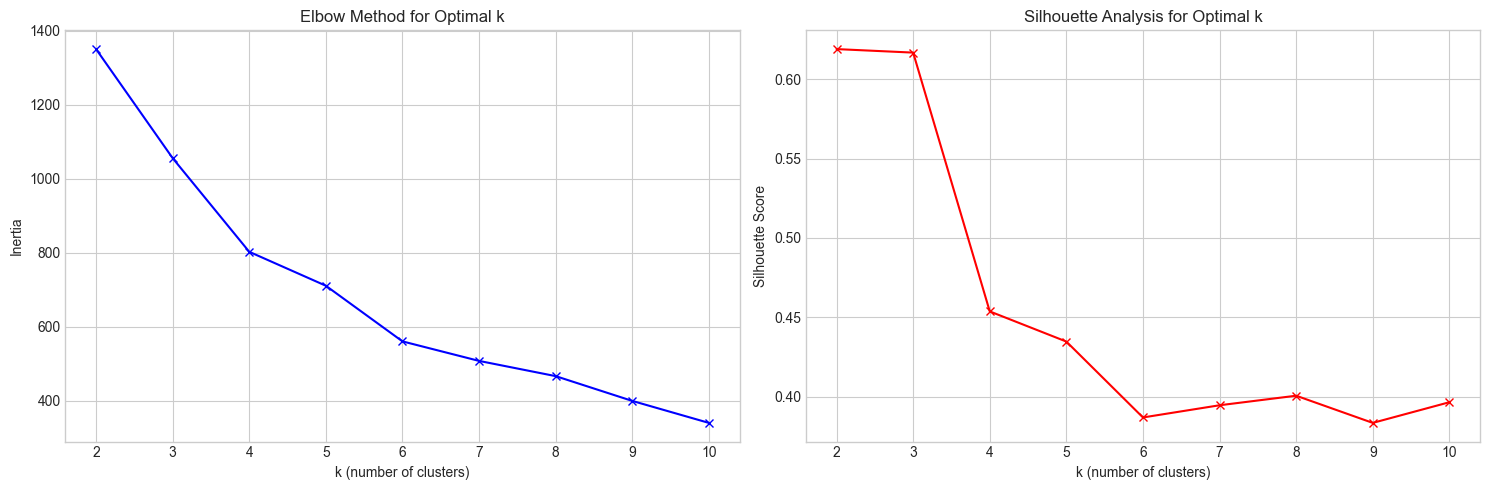


Elbow Method Inertias: [1349.8286788313212, 1055.1368074844154, 801.9896686546211, 710.3029383770859, 559.9354903308337, 507.15255030055624, 466.0194660810987, 399.04187064677296, 339.6406998687766]

Silhouette Scores: [np.float64(0.6188966089225925), np.float64(0.6166878343528961), np.float64(0.4537661982803577), np.float64(0.43477775195721846), np.float64(0.3869951711077722), np.float64(0.39468143120204285), np.float64(0.40068951969740857), np.float64(0.3835785373966163), np.float64(0.39659080294436505)]

=== Winger Clusters ===

Traditional Winger Profile:
- Ciro Immobile (Torino) - 27
- Riccardo Meggiorini (Chievo) - 27
- Cristian Portugués Manzanera (Real Sociedad) - 90
- Marius Wolf (Borussia Dortmund) - 281
- Zakaria Aboukhlal (Toulouse) - 235
- Steed Malbranque (Fulham) - 44
- Hirving Rodrigo Lozano Bahena (Mexico) - 106
- Blerim Džemaili (Genoa) - 27
- Patrick Wimmer (Austria) - 282
- Paul Pogba (Juventus) - 27
- Désiré Doué (Rennes) - 235
- Cristian Daniel Ansaldi (Genoa) - 

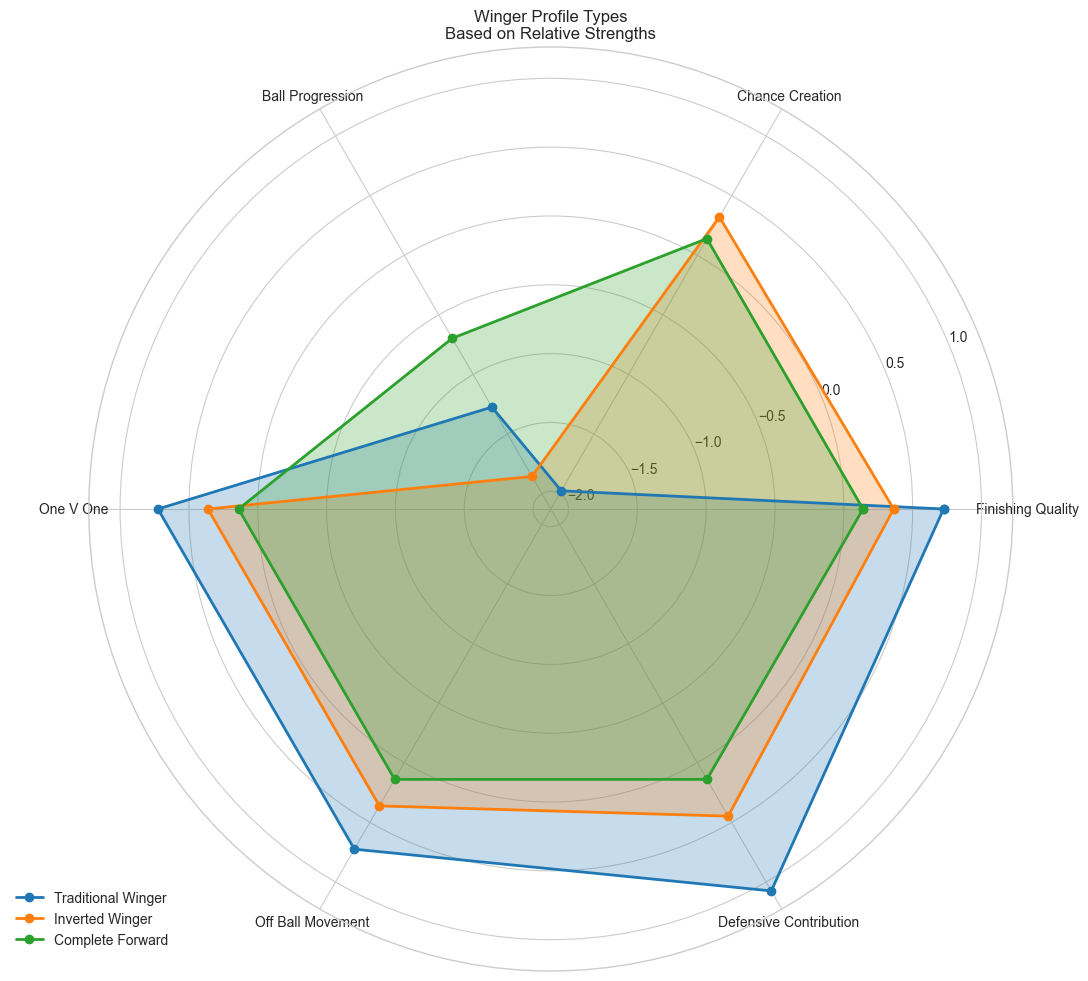


=== Cluster Summary Statistics ===

Traditional Winger Profile Summary:
Number of wingers: 414

Average absolute values:
finishing_quality         6.999855
chance_creation           4.299203
ball_progression          5.001570
one_v_one                 7.000000
off_ball_movement         7.000000
defensive_contribution    7.350000
dtype: float64

Standard deviations:
finishing_quality         0.002949
chance_creation           0.379442
ball_progression          0.311954
one_v_one                 0.000000
off_ball_movement         0.000000
defensive_contribution    0.371275
dtype: float64
--------------------------------------------------

Inverted Winger Profile Summary:
Number of wingers: 183

Average absolute values:
finishing_quality         7.000000
chance_creation           6.959399
ball_progression          4.782842
one_v_one                 7.000000
off_ball_movement         7.000000
defensive_contribution    7.085847
dtype: float64

Standard deviations:
finishing_quality        

<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Replace 4 with your actual number of cores

# Set style for visualizations
plt.style.use("seaborn-v0_8-whitegrid")

# Read the actual CSV file (assuming you have a similar CSV for wingers)
data = pd.read_csv('combined_winger_analysis.csv')

# Define features for analysis (based on winger metrics)
features = [
    'finishing_quality', 
    'chance_creation', 
    'ball_progression', 
    'one_v_one', 
    'off_ball_movement', 
    'defensive_contribution'
]

# Calculate relative strengths
winger_means = data[features].mean(axis=1)
relative_strengths = pd.DataFrame()
for feature in features:
    relative_strengths[feature] = data[feature] - winger_means

# First, analyze optimal number of clusters
print("Analyzing optimal number of clusters...")
max_clusters = 10
inertias = []
silhouette_scores = []

# Scale the data for analysis
scaler = StandardScaler()
scaled_data = scaler.fit_transform(relative_strengths)
scaled_df = pd.DataFrame(scaled_data, columns=features)

# Calculate metrics for different numbers of clusters
K = range(2, max_clusters + 1)
for k in K:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(scaled_df)
    inertias.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(scaled_df, kmeans_test.labels_))

# Plot validation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(K, inertias, 'bx-')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')

# Silhouette scores
ax2.plot(K, silhouette_scores, 'rx-')
ax2.set_xlabel('k (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis for Optimal k')

plt.tight_layout()
plt.show()

print("\nElbow Method Inertias:", inertias)
print("\nSilhouette Scores:", silhouette_scores)

# Proceed with original clustering using n_clusters=3
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(relative_strengths)

# Add cluster labels to data
data['cluster'] = labels
profile_styles = ['Traditional Winger', 'Inverted Winger', 'Complete Forward']

# Print clusters and their members
print("\n=== Winger Clusters ===")
for i in range(n_clusters):
    print(f"\n{profile_styles[i]} Profile:")
    cluster_wingers = data[data['cluster'] == i]
    for _, row in cluster_wingers.iterrows():
        print(f"- {row['player']} ({row['team']}) - {row['season_id']}")
    
    # Print relative strengths for this cluster
    print("\nCluster characteristics:")
    cluster_means = relative_strengths[data['cluster'] == i].mean()
    for feature in features:
        print(f"{feature}: {cluster_means[feature]:+.2f}")
    print("-" * 50)

# Create radar chart for cluster centers
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
for i in range(n_clusters):
    values = kmeans.cluster_centers_[i]
    values = np.concatenate((values, [values[0]]))
    ax.plot(angles, values, 'o-', linewidth=2, label=profile_styles[i])
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', ' ').title() for f in features])
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title("Winger Profile Types\nBased on Relative Strengths")
plt.show()





# Print summary statistics for each cluster
print("\n=== Cluster Summary Statistics ===")
for i in range(n_clusters):
    print(f"\n{profile_styles[i]} Profile Summary:")
    cluster_data = data[data['cluster'] == i]
    print(f"Number of wingers: {len(cluster_data)}")
    print("\nAverage absolute values:")
    print(cluster_data[features].mean())
    print("\nStandard deviations:")
    print(cluster_data[features].std())
    print("-" * 50)

# 1. Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(relative_strengths)

# 2. Apply PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 3. Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = data['cluster']  # Add cluster labels



# Add a brief explanation of the components
explained_var = pca.explained_variance_ratio_
plt.figtext(0.99, 0.01, 
            f'Explained variance: PC1={explained_var[0]:.2%}, PC2={explained_var[1]:.2%}',
            ha='right', fontsize=8)


# Print explained variance ratio
print("\nPrincipal Components Explained Variance Ratio:")
print(f"PC1: {explained_var[0]:.2%}")
print(f"PC2: {explained_var[1]:.2%}")

# Optional: Print cluster statistics
print("\nCluster Statistics:")
for i in range(3):
    print(f"\n{labels[i]}:")
    cluster_data = data[data['cluster'] == i]
    print(f"Number of players: {len(cluster_data)}")
    print("\nAverage attributes:")
    print(cluster_data[features].mean())

# Create DataFrame with cluster information
export_data = data[['player', 'team', 'season_id'] + features].copy()
export_data['cluster_profile'] = data['cluster'].map({
    0: 'Traditional Winger',
    1: 'Inverted Winger',
    2: 'Complete Forward'
})

# Add relative strength calculations
for feature in features:
    export_data[f'relative_{feature}'] = relative_strengths[feature]

# Sort by cluster and player name
export_data = export_data.sort_values(['cluster_profile', 'player'])

# Save to CSV
output_filename = 'winger_clusters_analysis.csv'
export_data.to_csv(output_filename, index=False)
print(f"\nCluster analysis exported to {output_filename}")
print(f"Total wingers analyzed: {len(export_data)}")
print("\nBreakdown by profile:")
print(export_data['cluster_profile'].value_counts().to_string())